# Follow-along — Recitation 3: PCA, and the rest of Assignment 1

**CPSY 1291 · Computational Cognitive Science · Brown University**

This notebook is the companion to **Recitation 3**, held the evening of the PCA
lecture and one week before Assignment 1 is due. It is **optional and
ungraded**. The parts marked **RUN WITH ME (in recitation)** are the ones we do
together; the parts marked **AT HOME** are for afterward. If you missed the
session, the notebook stands on its own; work top to bottom. It assumes the
numpy of Recitation 1.

**How the exercises work:** each exercise cell comes pre-filled with one
possible answer so the notebook runs cleanly end to end. Delete the sample
answer, write your own, and run the locked check cell below it. You cannot
break anything.

Open in Colab: **File → Upload notebook**, or run it locally. It needs only
numpy, matplotlib, scipy and scikit-learn.

## 1. A toy world with the ground truth planted — RUN WITH ME (in recitation)

One dataset threads through this notebook, and it is a miniature of Assignment
1's world. **Five toy objects** (a cube, a ball, a star, a cone, a torus) were
each photographed from **3 views** and pushed through a tiny **6-unit
network**, giving `F`: a `(15, 6)` **stimuli × units** matrix, one row per
stimulus, one column per unit.

We plant one fact in it: the five objects differ in **size**, 1 to 5, and the
network's response moves along one fixed direction as size grows. A real
network hides such facts; here we know they are there, so when a method
recovers the planted size we trust the method. That is the habit this notebook
drills, and it is why every exercise below can be checked.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.optimize import curve_fit
from scipy.stats import spearmanr, pointbiserialr
from sklearn.decomposition import PCA

rng = np.random.default_rng(1291)          # seeded: everyone sees the same numbers

n_obj, n_views, n_units = 5, 3, 6
obj = np.repeat(np.arange(n_obj), n_views)            # (15,) which object each row shows
obj_names = ["cube", "ball", "star", "cone", "torus"]
size = np.array([1.0, 2.0, 3.0, 4.0, 5.0])            # planted: one number per object

direction = rng.normal(size=n_units)                  # the axis size moves the response along
direction = direction / np.linalg.norm(direction)     # made unit length
proto = 1.5 * size[:, None] * direction + rng.normal(0.0, 0.6, size=(n_obj, n_units))
F = proto[obj] + rng.normal(0.0, 0.35, size=(n_obj * n_views, n_units))   # view jitter

print("F.shape:", F.shape, "  <- 15 stimuli (5 objects x 3 views), 6 units")
print("obj:    ", obj)
print("size of each stimulus's object:", size[obj])

F.shape: (15, 6)   <- 15 stimuli (5 objects x 3 views), 6 units
obj:     [0 0 0 1 1 1 2 2 2 3 3 3 4 4 4]
size of each stimulus's object: [1. 1. 1. 2. 2. 2. 3. 3. 3. 4. 4. 4. 5. 5. 5.]


## 2. PCA from the lecture, by hand — RUN WITH ME (in recitation)

The lecture said: centre the data, form the covariance matrix, take its
eigenvectors; the first eigenvector is the direction of largest variance and its
eigenvalue is the variance along it. Every word of that is a line of numpy. We
do it on **two units** first so it can be drawn, then on all six.

Start by picking the two units that co-vary most, so the cloud is visibly
tilted.

units 4 and 5 co-vary most: correlation -0.88


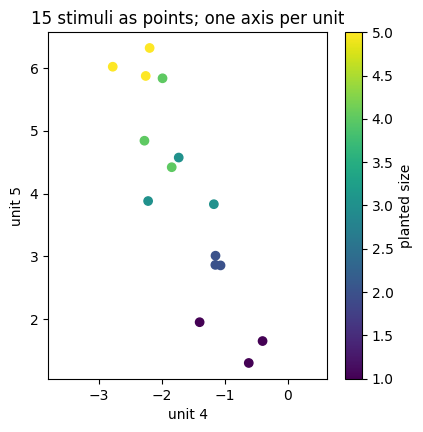

In [2]:
corr = np.corrcoef(F.T)                              # (6, 6): correlation between units
np.fill_diagonal(corr, 0)                            # ignore each unit with itself
u1, u2 = np.unravel_index(np.abs(corr).argmax(), corr.shape)
X2 = F[:, [u1, u2]]                                  # (15, 2): the two most correlated units
print(f"units {u1} and {u2} co-vary most: correlation {corr[u1, u2]:.2f}")

plt.figure(figsize=(4.5, 4.5))
plt.scatter(X2[:, 0], X2[:, 1], c=size[obj], cmap="viridis")
plt.colorbar(label="planted size")
plt.xlabel(f"unit {u1}")
plt.ylabel(f"unit {u2}")
plt.title("15 stimuli as points; one axis per unit")
plt.axis("equal")
plt.show()

Each stimulus is a point; the two axes are the two units. The cloud is tilted:
the two units rise and fall together across stimuli. That tilt is what PCA
finds.

**Step 1, centre.** Subtract each unit's mean, so the cloud sits at the origin.
**Step 2, covariance.** `Xc.T @ Xc / (n - 1)` is the $2 \times 2$ covariance
matrix: variances on the diagonal, the co-variation off it.

In [3]:
Xc = X2 - X2.mean(axis=0)                            # step 1: centre each unit (each column)
n = len(Xc)
C = Xc.T @ Xc / (n - 1)                              # step 2: the covariance matrix
print("covariance matrix C =")
print(C.round(3))
print("diagonal = variance of each unit:", Xc.var(axis=0, ddof=1).round(3))

covariance matrix C =
[[ 0.47  -0.994]
 [-0.994  2.719]]
diagonal = variance of each unit: [0.47  2.719]


**Step 3, eigenvectors.** `np.linalg.eigh` returns the eigenvalues of a
symmetric matrix in *ascending* order with the eigenvectors as *columns*, so we
flip both to get the largest first. Drawn on the cloud, the first eigenvector
points along the long axis; the second is perpendicular to it.

eigenvalues (variance along each eigenvector): [3.096 0.093]
first eigenvector (a unit vector, PC1 direction): [-0.354  0.935]
check: total variance 3.189 = sum of eigenvalues 3.189


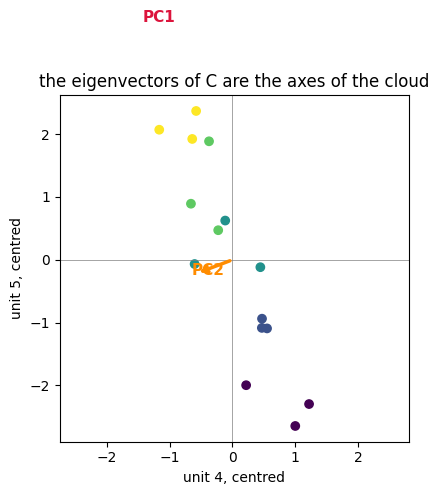

In [4]:
eigenvalues, eigenvectors = np.linalg.eigh(C)        # step 3
order = np.argsort(eigenvalues)[::-1]                # largest first
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]                # column k is the k-th eigenvector

print("eigenvalues (variance along each eigenvector):", eigenvalues.round(3))
print("first eigenvector (a unit vector, PC1 direction):", eigenvectors[:, 0].round(3))
print("check: total variance", Xc.var(axis=0, ddof=1).sum().round(3),
      "= sum of eigenvalues", eigenvalues.sum().round(3))

plt.figure(figsize=(4.5, 4.5))
plt.scatter(Xc[:, 0], Xc[:, 1], c=size[obj], cmap="viridis")
for k, colour in ((0, "crimson"), (1, "darkorange")):
    arrow = eigenvectors[:, k] * 2 * np.sqrt(eigenvalues[k])   # length ~ 2 standard deviations
    plt.annotate("", xy=arrow, xytext=(0, 0),
                 arrowprops=dict(arrowstyle="->", lw=2.5, color=colour))
    plt.text(*(arrow * 1.15), f"PC{k + 1}", color=colour, fontsize=11, weight="bold")
plt.axhline(0, color="grey", lw=0.5)
plt.axvline(0, color="grey", lw=0.5)
plt.xlabel(f"unit {u1}, centred")
plt.ylabel(f"unit {u2}, centred")
plt.title("the eigenvectors of C are the axes of the cloud")
plt.axis("equal")
plt.show()

**Step 4, project.** A stimulus's coordinate on PC1 is the dot product of its
centred response vector with the first eigenvector: `Xc @ v1`. Fifteen dot
products at once is one matrix product. And the variance of those coordinates
is the first eigenvalue, which is the whole reason PC1 is "the direction of
largest variance".

In [5]:
v1 = eigenvectors[:, 0]
pc1_scores = Xc @ v1                                  # step 4: one coordinate per stimulus
print("PC1 scores:", pc1_scores.round(2))
print("variance of the PC1 scores:", pc1_scores.var(ddof=1).round(3),
      " = first eigenvalue:", eigenvalues[0].round(3))

PC1 scores: [-2.58 -1.94 -2.83 -1.18 -1.04 -1.22 -0.27  0.62  0.15  1.07  0.52  1.9
  2.35  2.03  2.42]
variance of the PC1 scores: 3.096  = first eigenvalue: 3.096


### Exercise 2.1 — the second component, by hand — RUN WITH ME (in recitation)

Compute `pc2_scores`, every stimulus's coordinate on the **second** eigenvector,
and `var_pc2`, their variance (`ddof=1`). The check compares `var_pc2` with the
second eigenvalue. Then look at the two variances: how much of the cloud's
spread does PC1 alone carry?

In [6]:
pc2_scores = Xc @ eigenvectors[:, 1]        # one possible answer — delete and write your own
var_pc2 = pc2_scores.var(ddof=1)            # one possible answer — delete and write your own

In [7]:
# Check cell — run me, do not edit me.
assert getattr(pc2_scores, "shape", None) == (15,), (
    "pc2_scores should have one number per stimulus, shape (15,): Xc @ (second eigenvector). "
    "The second eigenvector is the second COLUMN of eigenvectors, eigenvectors[:, 1].")
assert abs(var_pc2 - eigenvalues[1]) < 1e-9, (
    "var_pc2 should equal the second eigenvalue exactly. Use ddof=1, the same convention "
    "as the covariance matrix (divided by n - 1).")
share = eigenvalues[0] / eigenvalues.sum()
print("Exercise 2.1 passed. PC1 carries", round(100 * share), "% of the variance of these")
print("two units; PC2 the remaining", round(100 * (1 - share)), "%. Two numbers per stimulus")
print("were nearly one number all along.")

Exercise 2.1 passed. PC1 carries 97 % of the variance of these
two units; PC2 the remaining 3 %. Two numbers per stimulus
were nearly one number all along.


### From two units to six, and to scikit-learn

Nothing changes with six units except that the covariance is $6 \times 6$ and
there are six eigenvectors, which no plot can show. That is the moment to let
`PCA` do the same four steps for you. Its `components_` are the eigenvectors
(stored as **rows**), its `explained_variance_` the eigenvalues, and
`fit_transform` returns the projections. Here the two routes are checked
against each other.

In [8]:
Fc = F - F.mean(axis=0)
C6 = Fc.T @ Fc / (len(Fc) - 1)
vals6, vecs6 = np.linalg.eigh(C6)
order6 = np.argsort(vals6)[::-1]
vals6, vecs6 = vals6[order6], vecs6[:, order6]

est = PCA()                                # settings go in the constructor (defaults here)
Y = est.fit_transform(F)                   # data goes to fit_transform; PCA centres for you

print("eigenvalues by hand:      ", vals6.round(3))
print("explained_variance_:      ", est.explained_variance_.round(3))
print("components_ == eigenvectors (up to sign):",
      np.allclose(np.abs(est.components_), np.abs(vecs6.T)))
print("fit_transform == Fc @ eigenvectors (up to sign):",
      np.allclose(np.abs(Y), np.abs(Fc @ vecs6)))

eigenvalues by hand:       [3.303 0.48  0.203 0.11  0.041 0.024]
explained_variance_:       [3.303 0.48  0.203 0.11  0.041 0.024]
components_ == eigenvectors (up to sign): True
fit_transform == Fc @ eigenvectors (up to sign): True


Two things to notice. The signs can differ: an eigenvector and its negative
describe the same axis, so PC1 and −PC1 are equally valid, and two machines can
legitimately disagree. Every check in this notebook compares absolute values
for that reason, and Assignment 1 grades accordingly. And the trailing
underscore on `explained_variance_` and `components_` is not a typo: it marks
what the estimator *learned*, which exists only after `.fit`.

## 3. How many components? — RUN WITH ME (in recitation)

`explained_variance_ratio_` is each eigenvalue divided by their sum. The
question "how many components reach 85%" is a running total (`cumsum`) and the
first index where a condition holds (`argmax` of a boolean array returns the
first `True`). Watch the off-by-one: `argmax` returns an index, indices start
at 0, so the **count** is index + 1.

variance ratio: [0.794 0.115 0.049 0.026 0.01  0.006]
cumulative:     [0.794 0.909 0.958 0.984 0.994 1.   ]
first index where cum >= 0.85: 1  -> that is 2 components


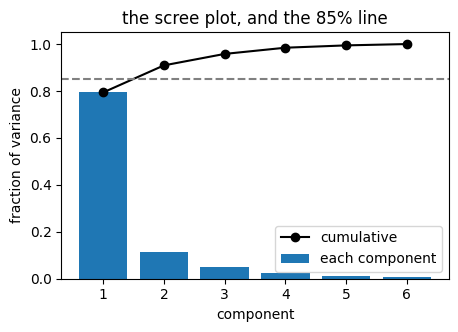

In [9]:
ratio = est.explained_variance_ratio_
cum = np.cumsum(ratio)
print("variance ratio:", ratio.round(3))
print("cumulative:    ", cum.round(3))
first = np.argmax(cum >= 0.85)
print("first index where cum >= 0.85:", first, " -> that is", first + 1, "components")

plt.figure(figsize=(5, 3.2))
plt.bar(np.arange(1, 7), ratio, label="each component")
plt.plot(np.arange(1, 7), cum, "o-", color="k", label="cumulative")
plt.axhline(0.85, ls="--", color="grey")
plt.xlabel("component")
plt.ylabel("fraction of variance")
plt.legend()
plt.title("the scree plot, and the 85% line")
plt.show()

"Two components explain 85% of the variance" sounds like a fact about the
network. Ask: out of how many possible components, on how many items? $n$ items
can never need more than $n - 1$ components, so raw counts are not comparable
across sets of different size. Here it is on the **five object means**: five
items, and the fifth eigenvalue is zero whatever the network did.

In [10]:
means = np.stack([F[obj == k].mean(axis=0) for k in range(n_obj)])    # (5, 6): one row per object
est_means = PCA().fit(means)
print("5 items -> eigenvalues:", est_means.explained_variance_.round(4))
print("nonzero components:", int((est_means.explained_variance_ > 1e-10).sum()), "of a possible", n_obj - 1)

5 items -> eigenvalues: [3.7179e+00 4.9190e-01 1.1500e-01 1.3000e-03 0.0000e+00]
nonzero components: 4 of a possible 4


### Exercise 3.1 — components to reach 95% — RUN WITH ME (in recitation)

Same move, higher bar, on the full `F`: compute `k95`, the **number of
components** (a count, not an index) whose cumulative explained variance first
reaches 0.95.

In [11]:
k95 = np.argmax(cum >= 0.95) + 1     # one possible answer — delete and write your own

In [12]:
# Check cell — run me, do not edit me.
assert k95 == 3, (
    f"k95 should be 3, not {k95}. If you are off by one, argmax returns the INDEX of "
    "the first True and indices start at 0; the count is index + 1. If you are far off, check "
    "the comparison: cum >= 0.95.")
print("Exercise 3.1 passed. In Assignment 1 this same line runs on real activations,")
print("and the question of what that count is a fact about is the assignment's, not ours.")

Exercise 3.1 passed. In Assignment 1 this same line runs on real activations,
and the question of what that count is a fact about is the assignment's, not ours.


## 4. The PC1–PC2 plane, and naming an axis — RUN WITH ME (in recitation)

Assignment 1 draws the 1,224 images in the plane of the first two components
and asks what the axes mean. Here is the same plot for 15 stimuli, and the
same question. We planted size, so PC1 *should* track it; the point is the
test, not the answer.

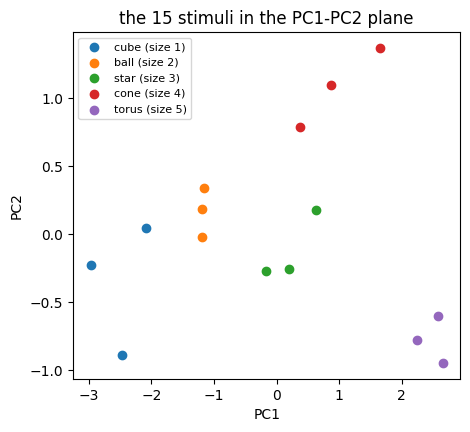

In [13]:
plt.figure(figsize=(5, 4.5))
for k in range(n_obj):
    pts = Y[obj == k]
    plt.scatter(pts[:, 0], pts[:, 1], label=f"{obj_names[k]} (size {size[k]:.0f})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("the 15 stimuli in the PC1-PC2 plane")
plt.legend(fontsize=8)
plt.show()

Five clumps of three: the first two axes already know there are five objects,
and they march along PC1 in size order. To *test* the name we hang on an axis,
correlate the axis's scores with the property, per stimulus. For a continuous
property (size) that is a Pearson or Spearman correlation; for a binary one
(round or not) it is the **point-biserial** correlation, which is Pearson with
a 0/1 variable. Both are one call.

In [14]:
is_round = np.array([0, 1, 0, 0, 1])         # ball and torus are round; nothing was planted here
rho_size = spearmanr(Y[:, 0], size[obj]).statistic
r_round = pointbiserialr(is_round[obj], Y[:, 0]).statistic
print(f"PC1 vs size (Spearman):        {rho_size:+.3f}   <- planted, so it should be strong")
print(f"PC1 vs roundness (point-biserial): {r_round:+.3f}   <- not planted, so it should be weak")

PC1 vs size (Spearman):        +0.971   <- planted, so it should be strong
PC1 vs roundness (point-biserial): +0.306   <- not planted, so it should be weak


### Exercise 4.1 — does PC2 know about size? — RUN WITH ME (in recitation)

Compute `rho_size_pc2`, the Spearman correlation between the **PC2** scores and
the stimuli's sizes. Before running it, predict: strong or weak? PC2 is
perpendicular to PC1, and PC1 already carries size.

In [15]:
rho_size_pc2 = spearmanr(Y[:, 1], size[obj]).statistic   # one possible answer — delete and write your own

In [16]:
# Check cell — run me, do not edit me.
assert np.ndim(rho_size_pc2) == 0, (
    "rho_size_pc2 should be one number: spearmanr(...).statistic, not the whole result object.")
assert abs(rho_size_pc2) < abs(rho_size), (
    "PC2 should track size less than PC1 does. Check that column 1 of Y (PC2) went in, "
    "and size[obj] (one size per stimulus), not size (one per object).")
print("Exercise 4.1 passed. |rho| for PC2:", round(abs(float(rho_size_pc2)), 3),
      "vs", round(abs(float(rho_size)), 3), "for PC1.")
print("An axis's name is a hypothesis, and a correlation is how you test it.")

Exercise 4.1 passed. |rho| for PC2: 0.098 vs 0.971 for PC1.
An axis's name is a hypothesis, and a correlation is how you test it.


## 5. Groupby without groupby, the template — RUN WITH ME (in recitation)

"Per-object anything" in pure numpy is one line with four moves. You already
ran it in section 3 to get the object means; here it is spelled out.

In [17]:
means = np.stack([F[obj == k].mean(axis=0) for k in range(n_obj)])
print("means.shape:", means.shape, " <- one mean response vector per object")

means.shape: (5, 6)  <- one mean response vector per object


1. `obj == k`: a boolean mask, which rows belong to object $k$
2. `F[obj == k]`: those rows, `(3, 6)`
3. `.mean(axis=0)`: collapse the 3 views, `(6,)`
4. `np.stack([...])`: pile the 5 results into one `(5, 6)` array

When an assignment says "for each object / category / cluster, compute ...",
this is the shape of the answer, with a different word in step 3.

### Exercise 5.1 — the template with a different word — RUN WITH ME (in recitation)

Compute `pc1_spread`: for each of the 5 objects, the **standard deviation** of
its 3 views' PC1 scores (`Y[:, 0]`). Shape `(5,)`. It says how much viewpoint
moves an object along PC1, the within-object spread that Assignment 1 asks
you to separate from the between-object spread.

In [18]:
pc1_spread = np.array([Y[obj == k, 0].std() for k in range(n_obj)])   # one possible answer — delete and write your own

In [19]:
# Check cell — run me, do not edit me.
assert getattr(pc1_spread, "shape", None) == (5,), (
    f"pc1_spread should have shape (5,), one number per object; yours is "
    f"{getattr(pc1_spread, 'shape', None)}. Mask Y[:, 0] with obj == k inside the template.")
assert np.all(pc1_spread < 1.0), (
    "The within-object spread along PC1 should be small (views jitter by 0.35): check that "
    "you took .std() of the three PC1 scores of ONE object, not of all 15.")
print("Exercise 5.1 passed. Within-object spread on PC1:", pc1_spread.round(2))
print("Compare the spacing of the five clumps in the plot above: between >> within.")

Exercise 5.1 passed. Within-object spread on PC1: [0.36 0.02 0.33 0.53 0.18]
Compare the spacing of the five clumps in the plot above: between >> within.


## 6. Fitting a curve and reading an R² — RUN WITH ME (in recitation)

Assignment 1 also asks whether similarity *ratings* fall off with distance as
Shepard's law says. We simulate a participant who obeys a **planted law**,
$s = 10\,e^{-0.8\,d}$ plus noise, so we can tell whether the pipeline recovers
$a = 10$ and $b = 0.8$.

planted:   a = 10.00  b = 0.80
recovered: a = 9.61  b = 0.77
R2 line: 0.75    R2 exponential: 0.94


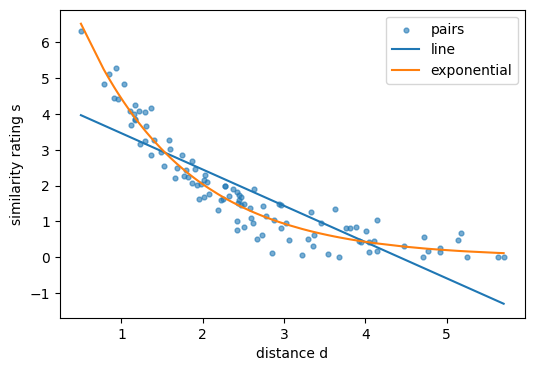

In [20]:
d = pdist(F)                                   # every pair of stimuli once: 105 distances
s = 10.0 * np.exp(-0.8 * d) + rng.normal(0.0, 0.4, size=d.shape)
s = np.clip(s, 0.0, 10.0)                      # ratings live on a 0-10 scale


def f_exp(d, a, b):
    return a * np.exp(-b * d)


def f_gauss(d, a, b):
    return a * np.exp(-b * d ** 2)


def r2(y, yhat):
    return 1 - ((y - yhat) ** 2).sum() / ((y - y.mean()) ** 2).sum()


popt, _ = curve_fit(f_exp, d, s, p0=[10, 1], maxfev=40000)   # returns (parameters, covariance)
y_exp = f_exp(d, *popt)                                       # * unpacks the parameters back in
coef = np.polyfit(d, s, 1)                                    # a straight line, for comparison
y_lin = np.polyval(coef, d)

print("planted:   a = 10.00  b = 0.80")
print("recovered: a =", popt[0].round(2), " b =", popt[1].round(2))
print("R2 line:", round(r2(s, y_lin), 2), "   R2 exponential:", round(r2(s, y_exp), 2))

ds = np.sort(d)
plt.figure(figsize=(6, 4))
plt.scatter(d, s, s=12, alpha=0.6, label="pairs")
plt.plot(ds, np.polyval(coef, ds), label="line")
plt.plot(ds, f_exp(ds, *popt), label="exponential")
plt.xlabel("distance d")
plt.ylabel("similarity rating s")
plt.legend()
plt.show()

Three things about `curve_fit` that students otherwise learn the hard way: it
returns a tuple, parameters first; the fitted parameters go back into your own
function with a `*`; and `p0` should start at the scale of the data (ratings
run 0 to 10, so $a \approx 10$). Both models are scored by the **same** `r2`
against the **same** `s`. The plot shows what the numbers cannot: the line goes
negative at large distances, where a rating never can.

$R^2 = 1 - \sum(y - \hat y)^2 / \sum(y - \bar y)^2$: the fraction of the
mean-predictor's error that the curve removes. It is 1 when perfect, 0 when no
better than the mean, and negative when worse.

### Exercise 6.1 — the rival law — RUN WITH ME (in recitation)

Shepard's exponential has a rival, the Gaussian `f_gauss`, flat near $d = 0$
where the exponential already plunges. Fit it with the same `curve_fit` call,
evaluate it, and score it into `r2_gauss` with the same scorer and target.

In [21]:
popt_g, _ = curve_fit(f_gauss, d, s, p0=[10, 1], maxfev=40000)  # one possible answer — delete and write your own
r2_gauss = r2(s, f_gauss(d, *popt_g))                           # one possible answer — delete and write your own

In [22]:
# Check cell — run me, do not edit me.
assert np.ndim(r2_gauss) == 0, "r2_gauss should be one number: r2(s, f_gauss(d, *popt_g))."
assert r2_gauss < r2(s, y_exp), (
    "The Gaussian should score below the exponential here, because the exponential is the "
    "truth we planted. If not, a fit got scored against the wrong target.")
print("Exercise 6.1 passed. R2:", round(r2(s, y_lin), 2), "(line) <",
      round(float(r2_gauss), 2), "(Gaussian) <", round(r2(s, y_exp), 2), "(exponential).")
print("The exponential wins because we planted it. Assignment 1 asks the same")
print("question of data where nobody planted anything.")

Exercise 6.1 passed. R2: 0.75 (line) < 0.91 (Gaussian) < 0.94 (exponential).
The exponential wins because we planted it. Assignment 1 asks the same
question of data where nobody planted anything.


## 7. Comparing two RDMs — RUN WITH ME (in recitation)

A representational dissimilarity matrix (RDM) holds the distance between every
pair of stimuli. To compare two RDMs, take each one's **upper triangle in fixed
pair order** and Spearman-correlate the two vectors. Here: the full network
against a recording that caught only the first three units.

rho (upper triangles): 0.483
rho (whole matrices):  0.58  <- inflated: every pair twice, plus 15 shared zeros


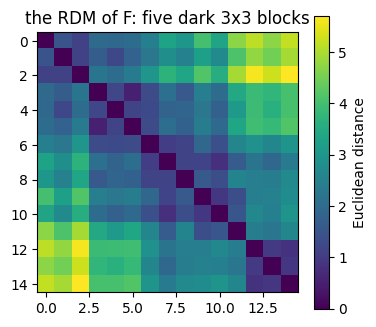

In [23]:
D = squareform(d)                                     # (15, 15) square RDM from the condensed d
D_early = squareform(pdist(F[:, :3]))                 # RDM from units 0-2 only
iu = np.triu_indices(15, k=1)                         # each pair once, no diagonal

rho = spearmanr(D[iu], D_early[iu]).statistic
print("rho (upper triangles):", round(rho, 3))
print("rho (whole matrices): ", round(spearmanr(D.ravel(), D_early.ravel()).statistic, 3),
      " <- inflated: every pair twice, plus 15 shared zeros")

plt.figure(figsize=(4.2, 3.8))
plt.imshow(D)
plt.colorbar(label="Euclidean distance")
plt.title("the RDM of F: five dark 3x3 blocks")
plt.show()

### Exercise 7.1 — which half carries the geometry? — RUN WITH ME (in recitation)

Build `D_late`, the RDM from the **last three units** (`F[:, 3:]`), and
`rho_late`, its Spearman correlation with the full `D`, upper triangles only.
Which three units carry more of the full geometry?

In [24]:
D_late = squareform(pdist(F[:, 3:]))                 # one possible answer — delete and write your own
rho_late = spearmanr(D[iu], D_late[iu]).statistic    # one possible answer — delete and write your own

In [25]:
# Check cell — run me, do not edit me.
assert getattr(D_late, "shape", None) == (15, 15), (
    "D_late should be the (15, 15) square RDM built from F[:, 3:]: pdist gives condensed, "
    "squareform makes it square.")
assert np.ndim(rho_late) == 0, "rho_late should be a single number: spearmanr(...).statistic."
assert abs(rho_late - 0.950) < 0.005, (
    "rho_late is off. Two usual causes: the full matrices went in instead of the upper "
    "triangles (use [iu] on BOTH), or D_late was built from the wrong columns.")
print("Exercise 7.1 passed. rho_late =", round(float(rho_late), 3), "vs", round(float(rho), 3),
      "for the first three units.")
print("Assignment 1 builds its whole layers-versus-behaviour table from this one line.")

Exercise 7.1 passed. rho_late = 0.95 vs 0.483 for the first three units.
Assignment 1 builds its whole layers-versus-behaviour table from this one line.


## 8. AT HOME — `components_`, and which way to multiply

scikit-learn stores the eigenvectors in `components_` **as rows**,
`(n_components, n_units)`. To project by hand you must transpose them, and you
must centre first, because PCA centred for you. Trigger the shape error on
purpose, so the first time you meet it is here.

In [26]:
est2 = PCA(n_components=2)
Y2 = est2.fit_transform(F)
print("components_.shape:", est2.components_.shape, " <- directions are ROWS")
print("Fc @ components_.T reproduces fit_transform:", np.allclose(Fc @ est2.components_.T, Y2))
try:
    Fc @ est2.components_
except ValueError as e:
    print("without the transpose -> ValueError:", e)

components_.shape: (2, 6)  <- directions are ROWS
Fc @ components_.T reproduces fit_transform: True
without the transpose -> ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 6)


### Exercise 8.1 — reproduce fit_transform yourself — AT HOME

Fit `est3 = PCA(n_components=3)` on `F` and build `Y3_mine` by hand: centre
`F`, then one matrix product with `est3.components_`. The check compares you
against `est3.transform(F)`.

In [27]:
est3 = PCA(n_components=3).fit(F)                    # one possible answer — delete and write your own
Y3_mine = (F - F.mean(axis=0)) @ est3.components_.T  # one possible answer — delete and write your own

In [28]:
# Check cell — run me, do not edit me.
assert getattr(Y3_mine, "shape", None) == (15, 3), (
    f"Y3_mine should be (15, 3); yours is {getattr(Y3_mine, 'shape', None)}. If you hit the "
    "ValueError above, components_ is (3, 6) and needs the .T.")
assert np.allclose(Y3_mine, est3.transform(F)), (
    "Right shape, wrong values: most often the centring step was skipped. Subtract "
    "F.mean(axis=0) before multiplying.")
print("Exercise 8.1 passed. Centre, then project: that is all fit_transform does.")

Exercise 8.1 passed. Centre, then project: that is all fit_transform does.


## 9. AT HOME — a method with a knob: `random_state` and perplexity

Assignment 1's last part uses t-SNE, which starts from a random layout and has
a knob called perplexity. Two runs without a seed give two different maps of
the same data; two runs with the same `random_state` give the same map; two
perplexities give two different pictures that are both "correct". A method
with a knob does not give you a result, it gives you a family of results, and
the assignment asks you to say what survives across the family.

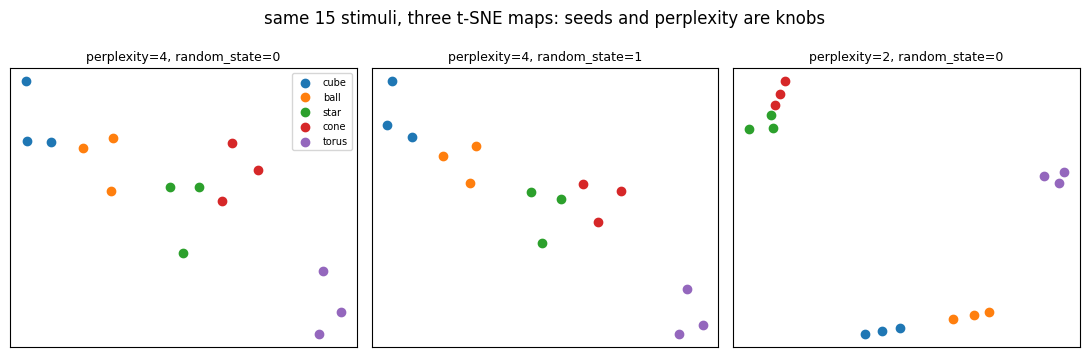

In [29]:
from sklearn.manifold import TSNE

fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
settings = [dict(perplexity=4, random_state=0), dict(perplexity=4, random_state=1),
            dict(perplexity=2, random_state=0)]
for axis, kwargs in zip(axes, settings):
    Z = TSNE(n_components=2, init="random", **kwargs).fit_transform(F)
    for k in range(n_obj):
        axis.scatter(Z[obj == k, 0], Z[obj == k, 1], label=obj_names[k])
    axis.set_title(", ".join(f"{key}={value}" for key, value in kwargs.items()), fontsize=9)
    axis.set_xticks([])
    axis.set_yticks([])
axes[0].legend(fontsize=7)
plt.suptitle("same 15 stimuli, three t-SNE maps: seeds and perplexity are knobs")
plt.tight_layout()
plt.show()

What survives across the three maps? The five clumps. What does not? Their
positions, their distances from one another, and the orientation of the whole
picture. That distinction is the assignment's last question in a sentence.

## 10. AT HOME — the skeleton corner

Three things Assignment 1's test-solve showed stop people cold, each running
here on the toy world. Nothing below is a solution to a graded question.

### 10a. The variance split: identity versus viewpoint

How much of the spread in `F` is objects differing from each other, and how
much is views of one object differing? Three lines, using `means` from
section 5.

In [30]:
total = F.var(axis=0).sum()          # variance per unit, summed: one number
between = means.var(axis=0).sum()    # variance OF the 5 object means
within = total - between             # what viewpoint contributes
print("total:", total.round(3), "  between (identity):", between.round(3),
      "  within (viewpoint):", within.round(3), "  identity share:", round(between / total, 3))
within_direct = np.mean([F[obj == k].var(axis=0) for k in range(n_obj)], axis=0).sum()
print("within by subtraction == within computed directly:", np.allclose(within, within_direct))

total: 3.884   between (identity): 3.461   within (viewpoint): 0.423   identity share: 0.891
within by subtraction == within computed directly: True


### 10b. Missing values: pick one, and say which

Real electrodes drop samples; PCA accepts none of it. We plant a few NaNs in a
copy of `F`, then show the two defensible one-liners: **drop** the affected
units, or **impute** each unit's mean into its holes. Either is defensible; the
graded habit is saying which you chose and why. And check for zero-variance
units before z-scoring: dividing by a standard deviation of 0 makes NaNs, and
one NaN poisons everything downstream.

In [31]:
rng_nan = np.random.default_rng(7)
it_raw = F.copy()
it_raw[rng_nan.integers(0, 15, 4), 1] = np.nan    # unit 1 dropped some samples
it_raw[rng_nan.integers(0, 15, 3), 4] = np.nan    # so did unit 4
print("NaNs planted:", np.isnan(it_raw).sum(), "  affected units:", np.where(np.isnan(it_raw).any(axis=0))[0])

dropped = it_raw[:, ~np.isnan(it_raw).any(axis=0)]                        # DROP affected units
imputed = np.where(np.isnan(it_raw), np.nanmean(it_raw, axis=0), it_raw)  # IMPUTE unit means
print("drop ->", dropped.shape, "  impute ->", imputed.shape)

NaNs planted: 7   affected units: [1 4]
drop -> (15, 4)   impute -> (15, 6)


### 10c. A loop over fits, and a fit that is allowed to fail

The assignment runs the fitting code several times (layers × networks). The
blocker is never the fitting, it is the plumbing, and one fit may legitimately
fail to converge on an untrained layer: that failure is a finding, not a bug.
Here the same loop on the toy world, matched ratings against ratings
**shuffled** so the law is destroyed.

In [32]:
rng_sh = np.random.default_rng(3)
for tag, y in (("matched ", s), ("shuffled", rng_sh.permutation(s))):
    try:
        p_fit, _ = curve_fit(f_exp, d, y, p0=[10, 1], maxfev=40000)
        print(tag, " a =", p_fit[0].round(2), " b =", p_fit[1].round(2),
              " R2 =", round(r2(y, f_exp(d, *p_fit)), 3))
    except RuntimeError as e:
        print(tag, " fit did not converge:", e)

matched   a = 9.61  b = 0.77  R2 = 0.939
shuffled  a = 2.0  b = 0.03  R2 = 0.003


## 11. Where this goes next

You have now done, on a world you built yourself, every step the PCA lecture
described (centre, covariance, eigenvectors, project, and the eigenvalue as
the variance along an axis) and every pipeline Assignment 1 leans on: the
scikit-learn pattern, variance explained and the $n - 1$ bound, naming an axis
with a correlation, the groupby template, curve fitting and $R^2$, RDM
comparison on the upper triangle, and the knobs of t-SNE. The
[Recitation 3 deck](https://serre-lab.github.io/CPSY1291-2026/recitations/recitation-03-pca-and-the-rest-of-A1.html)
covers the same ground on slides.

This notebook, like the recitations, is **optional and ungraded**. Bring the
parts that resisted you to office hours, with the failing cell open and its
shapes already printed.